# One-dimensional Regression with NNs (Flax)

We want to approximate the following unkown (scalar real-valued) function $f\colon D \subset \mathbb{R} \rightarrow \mathbb{R}$ with a neural network model given input-output $K$ pairs $(x^{(k)}, y^{(k)})_{k=1}^K$ of the data.

This notebook uses the **Flax** module for the MLP neural network and the **Optax** optimizer wrapped in `nnx.Optimizer`.

Import dependencies

In [10]:
from time import time

import matplotlib.pyplot as plt
import jax
from jax import numpy as jnp
from jaxtyping import Array, PyTree
import optax
from flax import nnx
from sklearn.metrics import r2_score

jax.config.update("jax_enable_x64", True)

Define *target function*. For instance, $x \mapsto f(x) = \sqrt{|x|}$

In [11]:
def f_fn(x: Array):
    return jnp.sqrt(jnp.abs(x))
    #return jnp.pow(x, 2)
    #return jnp.exp(x)
    #return jnp.sin(jnp.pi *x)

Get training data by using the discretized 1-dimensional grid as the input

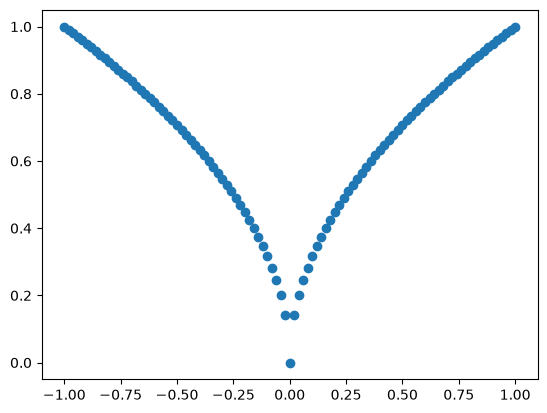

In [12]:
N = 101
x_min, x_max = -1, 1
x_train = jnp.linspace(x_min, x_max, N).reshape(-1, 1)
y_train = f_fn(x_train)
plt.scatter(x_train, y_train);

Build a _multilayer perceptron (MLP)_ feedforward neural network

With Flax NNX, the model owns its parameters as regular Python attributes (created eagerly in `__init__`), instead of returning a separate pytree of params like the hand-rolled version did.

In [18]:
class MLP(nnx.Module):
    '''
    Simple feedforward MLP: a stack of nnx.Linear layers with a
    tanh activation between hidden layers, and a linear (identity)
    output layer.
    '''
    def __init__(self, d_in: int, d_hiddens: list[int], d_out: int, *, rngs: nnx.Rngs):
        dims = [d_in] + d_hiddens + [d_out]
        # keep params in float64 to match `jax_enable_x64` above
        # nnx.List wraps the list of submodules so NNX tracks them as
        # part of the model's state (a plain python list is treated as static)
        self.layers = nnx.List([
            nnx.Linear(n_in, n_out, param_dtype=jnp.float64, rngs=rngs)
            for n_in, n_out in zip(dims[:-1], dims[1:])
        ])

    def __call__(self, x: Array) -> Array:
        *hidden, last = self.layers
        for layer in hidden:
            x = jax.nn.tanh(layer(x))
        return last(x)

Set neural network architecture and initialize the model. Unlike the hand-made version, initialization happens as soon as the module is constructed

In [19]:
# set input, output and hidden dimensions
d_in, d_hiddens, d_out = 1, [32, 16, 8], 1
model = MLP(d_in, d_hiddens, d_out, rngs=nnx.Rngs(0))

# check shapes of the learnable parameters
jax.tree_util.tree_map(jnp.shape, nnx.state(model, nnx.Param))

State({
  'layers': {
    0: {
      'bias': Param(
        value=(32,)
      ),
      'kernel': Param(
        value=(1, 32)
      )
    },
    1: {
      'bias': Param(
        value=(16,)
      ),
      'kernel': Param(
        value=(32, 16)
      )
    },
    2: {
      'bias': Param(
        value=(8,)
      ),
      'kernel': Param(
        value=(16, 8)
      )
    },
    3: {
      'bias': Param(
        value=(1,)
      ),
      'kernel': Param(
        value=(8, 1)
      )
    }
  }
})

Note that the forward pass with `flax.nnx` model is called directly, without having to separately define a `forward(params, x)` function.

In [20]:
y_init = model(x_train)

Define MSE loss

In [21]:
def loss_fn(model: MLP, x: Array, y: Array) -> Array:
    '''
    Computes mean square error (mse) between the target function and the model
    '''
    y_pred = model(x)
    return jnp.mean((y_pred - y) ** 2)

Initialize the **optax** optimizer wrapped in `nnx.Optimizer`

In [22]:
lr = 1e-2
optimizer = nnx.Optimizer(model, optax.adam(lr), wrt=nnx.Param)

Define the train step function.

In [23]:
@nnx.jit
def train_step(model: MLP, optimizer: nnx.Optimizer, x: Array, y: Array) -> Array:
    '''
    Evaluates loss, computes gradients and updates model parameters in place using SGD.
    '''
    loss_value, grads = nnx.value_and_grad(loss_fn)(model, x, y)
    optimizer.update(model, grads)
    return loss_value

Train

In [24]:
n_iter = int(1e4)
log_period_iter = int(1e3)
for i in range(n_iter):
    t0 = time()
    loss_value = train_step(model, optimizer, x_train, y_train)
    t1 = time()
    if i % log_period_iter == 0:
        print('it: {:d}, loss: {:.3e}, time: {:.4f}s'.format(i, loss_value, t1 - t0))

it: 0, loss: 5.125e-01, time: 0.2176s
it: 1000, loss: 1.246e-04, time: 0.0007s
it: 2000, loss: 5.068e-05, time: 0.0007s
it: 3000, loss: 1.083e-05, time: 0.0007s
it: 4000, loss: 3.815e-06, time: 0.0007s
it: 5000, loss: 2.417e-06, time: 0.0007s
it: 6000, loss: 9.314e-06, time: 0.0006s
it: 7000, loss: 4.247e-07, time: 0.0007s
it: 8000, loss: 8.025e-05, time: 0.0007s
it: 9000, loss: 6.920e-07, time: 0.0006s


Evaluate results

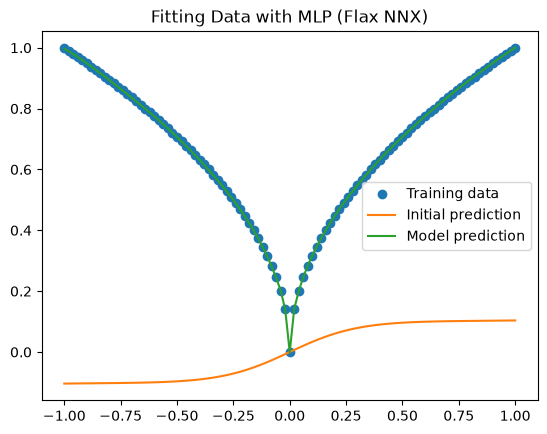

In [25]:
y_pred = model(x_train)
fig, ax = plt.subplots()
ax.set_title('Fitting Data with MLP (Flax NNX)');
ax.scatter(x_train, y_train, c='tab:blue', label='Training data')
ax.plot(x_train, y_init, c='tab:orange', label='Initial prediction')
ax.plot(x_train, y_pred, c='tab:green', label='Model prediction')
ax.legend();

Compute _r2 score_

In [26]:
r2 = round(float(r2_score(y_train, y_pred)), 3)
print("R^2 Score:", r2)

R^2 Score: 1.0
